*   ****MEMPREDIKSI NILAI DARI HASIL JAM BELAJAR SISWA****

****Modul 1**** (Data Understanding)

* Import library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.float_format', lambda x: '%.4f' % x)

* Membaca file CSV

In [2]:
df = pd.read_csv('student_perform.csv')

* Menampilkan 5 data teratas

In [3]:
df.head()

,study_hours,exam_score
0,1.2000,42
1,8.5000,95
2,5.4000,78
3,3.1000,55
4,9.8000,99


* Menampilkan 5 data terbawah

In [4]:
df.tail()

,study_hours,exam_score
634,5.7000,84
635,0.3000,37
636,8.7000,100
637,3.4000,67
638,7.9000,99


* Menampilkan deskripsi data

In [5]:
df.describe()

,study_hours,exam_score
count,639.0000,639.0000
mean,4.9986,74.0016
std,2.7463,20.9305
min,0.1000,31.0000
25%,2.7000,57.0000
50%,5.0000,76.0000
75%,7.3000,93.0000
max,9.9000,100.0000


* Menampilkan informasi data

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 639 entries, 0 to 638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  639 non-null    float64
 1   exam_score   639 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 10.1 KB


* Menampilkan data kosong

In [7]:
df.isna().sum()

study_hours    0
exam_score     0
dtype: int64

*    * Tidak ada data kosong*

* Menampilkan data duplikat

In [8]:
def cek_duplicate(df):
    duplicated_df = df[df.duplicated(keep = False)]
    index_list = duplicated_df.index.to_list()
    print (f'Kolom yang Terduplikat : ')
    print (duplicated_df)
    print (f'Jumlah Duplikat Data {df.duplicated().sum()}')
    print (f'Baris : {index_list}')

In [9]:
cek_duplicate(df)

Kolom yang Terduplikat : 
     study_hours  exam_score
2         5.4000          78
7         4.5000          72
8         0.5000          35
9         7.3000          92
10        2.9000          58
..           ...         ...
620       9.1000         100
626       8.9000         100
630       9.4000         100
634       5.7000          84
636       8.7000         100

[387 rows x 2 columns]
Jumlah Duplikat Data 230
Baris : [2, 7, 8, 9, 10, 11, 13, 15, 17, 18, 20, 22, 24, 25, 27, 28, 29, 30, 31, 32, 34, 36, 37, 39, 40, 41, 43, 44, 45, 46, 48, 50, 52, 54, 55, 57, 58, 59, 61, 62, 64, 65, 66, 67, 68, 69, 72, 73, 75, 76, 77, 78, 79, 80, 81, 83, 84, 85, 86, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 101, 103, 105, 106, 107, 108, 109, 110, 112, 114, 115, 118, 119, 120, 122, 123, 125, 126, 128, 129, 131, 132, 133, 134, 136, 139, 140, 141, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 157, 160, 162, 163, 164, 165, 167, 168, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 182, 18

*   *  230 Data duplikat

**Modul 2** (EDA)

* Menampilkan data berbentuk histplot (Melihat distribusi data)

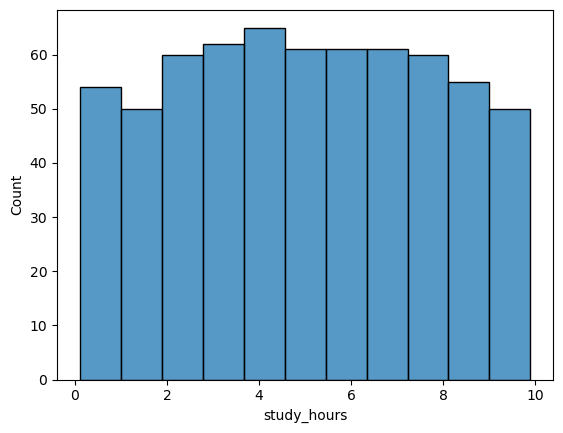

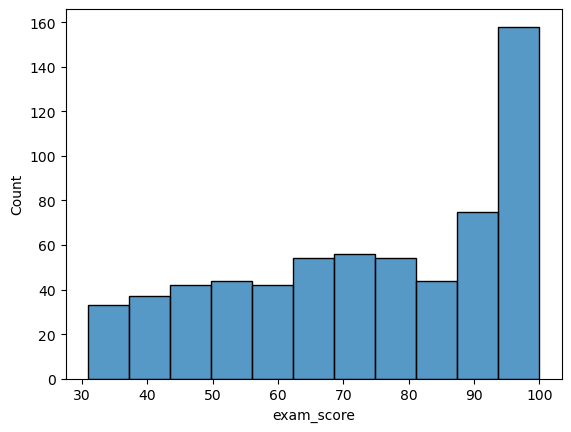

In [10]:
for i in df.columns:
    sns.histplot(df[i])
    plt.show()

* Menampilkan data berbentuk boxplot (Melihat sebaran outlier)

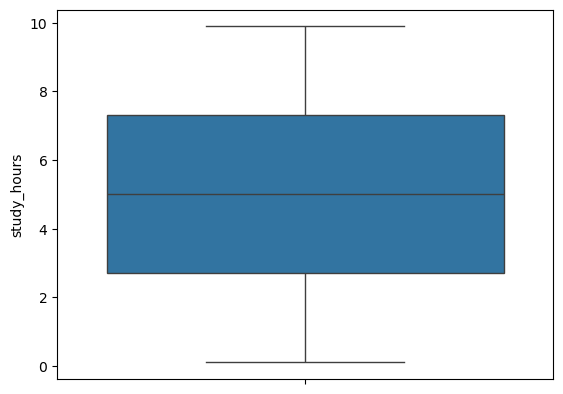

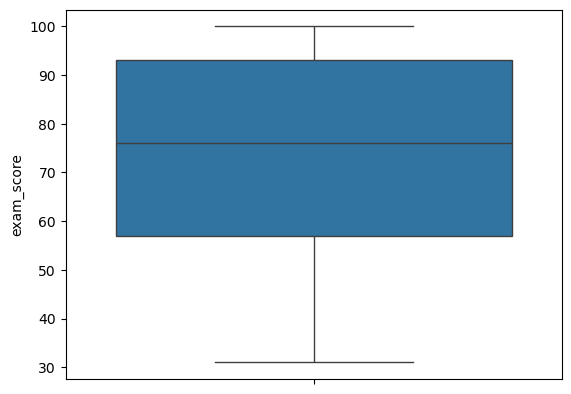

In [11]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

*     Karena tidak ada outlier jadi langsung ke tahap pemodelan

* Menampilkan data menggunakan pairplot

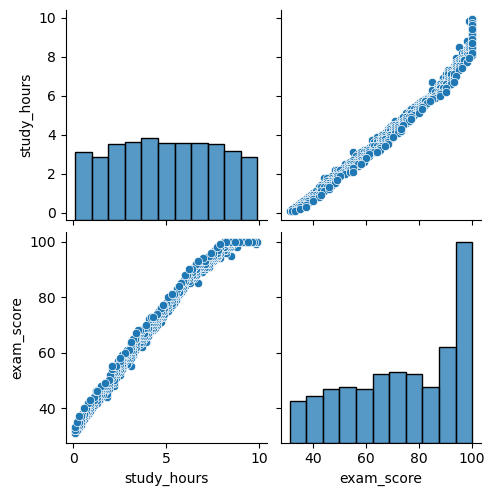

In [12]:
sns.pairplot(df)

* Menampilkan data menggunakan heatmap (Melihat korelasi data)

<Axes: >

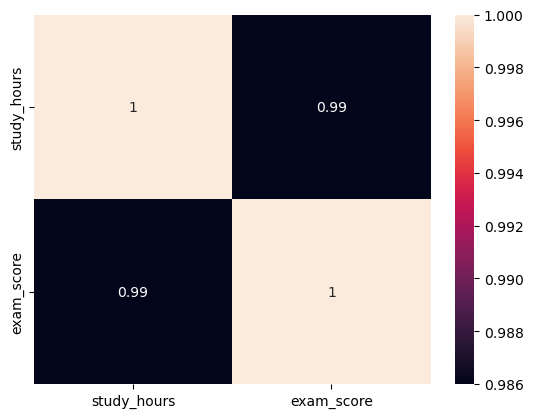

In [13]:
sns.heatmap(df.corr(), annot=True)

*   * Mendekat ke angka +1 korelasi positif menguat (Searah)
*   * Mendekat ke angka -1 korelasi negatif menguat (Tidak searah)
*   * Jika korelasi di angka 0 maka tidak ada korelasi dari data tersebut

**Modul 3** (Data Processing)

*   * *Sedikit yang di lakukan di modul ke 3 karena tidak ada outlier yang harus di tangani dan tidak ada data kosong harus di tangani juga*

* Menghapus data duplikat

In [14]:
df.drop_duplicates()

,study_hours,exam_score
0,1.2000,42
1,8.5000,95
2,5.4000,78
3,3.1000,55
4,9.8000,99
...,...,...
632,6.2000,90
633,1.7000,49
635,0.3000,37
637,3.4000,67


* Melihat hasil menggunakan paiplot

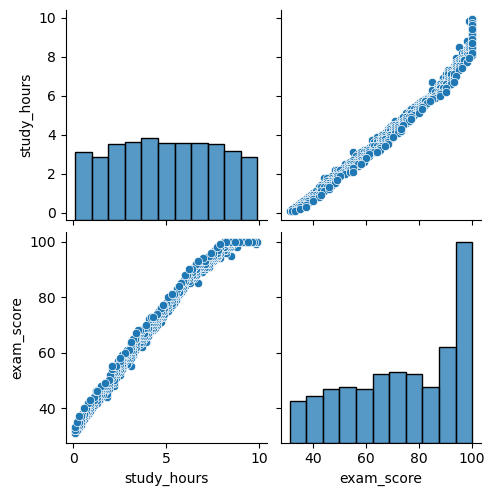

In [15]:
sns.pairplot(df)

**Modul 4** (Pemodelan)

* Spliting data

In [16]:
df_train = df.sample(frac=0.8, random_state=42)
df_test = df.drop(df_train.index)

* Feature sellection & Feature scalling (Standarisasi)

In [17]:
x_train = df_train ['study_hours']
y_train = df_train ['exam_score']
x_train_std = x_train.std()

x_tr_stdz = (x_train - x_train.mean()) / x_train_std
x_test = df['study_hours']

x_te_stdz = (x_test - x_train.mean()) / x_train_std
y_test = df['exam_score']

In [18]:
x_tr_stdz.describe()

count   511.0000
mean     -0.0000
std       1.0000
min      -1.8216
25%      -0.8180
50%       0.0032
75%       0.8426
max       1.7551
Name: study_hours, dtype: float64

In [19]:
x_te_stdz.describe()

count   639.0000
mean     -0.0338
std       1.0023
min      -1.8216
25%      -0.8727
50%      -0.0333
75%       0.8061
max       1.7551
Name: study_hours, dtype: float64

* Rumus Linear Regression

In [20]:
class linearRegression:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, x, y):
        self.m = (len(x) * np.sum(x * y) - np.sum(x) * np.sum(y)) / (len(x) * np.sum(x**2) - np.sum(x)**2)
        self.b = (np.sum(y) - self.m * np.sum(x)) / len(x)

    def predict(self, x):
        y = self.m * x + self.b
        return y

In [21]:
model = linearRegression()
model.fit(x_tr_stdz, y_train)

In [22]:
y_pred_train = model.predict(x_tr_stdz)
y_pred_test = model.predict(x_te_stdz)

**Modul 5** (Evaluasi)

* Fungsi evaluasi 

In [23]:
def eval(y, y_pred):
    r_squared = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2))
    mse = np.mean((y - y_pred)**2)
    mae = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(mse)
    print(f'Root Squared : {r_squared * 100:.2f}%')
    print(f'MSE : {mse}')
    print(f'MAE : {mae}')
    print(f'RMSE : {rmse}')

* Evaluasi data train dan data test

In [24]:
eval(y_train, y_pred_train)

Root Squared : 97.18%
MSE : 12.128381783482801
MAE : 2.7922390186862054
RMSE : 3.482582631249803


In [25]:
eval(y_test, y_pred_test)

Root Squared : 97.21%
MSE : 12.182780233703815
MAE : 2.796627387522577
RMSE : 3.490383966514832


*   * MSE (Mean Square error)
*   * MAE (Mean Absolute error)
*   * RMSE (Root Mean Square error)

* Hasil dari data prediksi

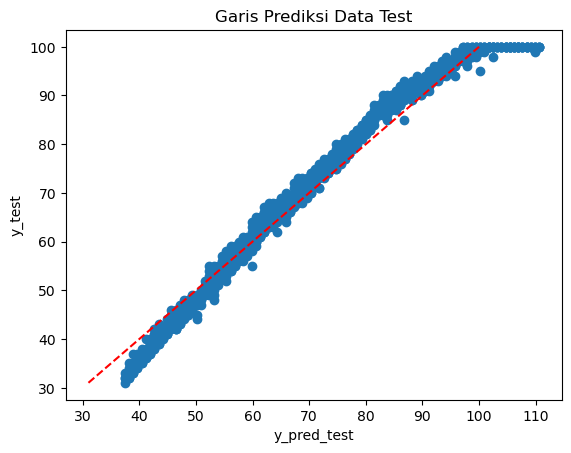

In [26]:
plt.scatter(y_pred_test, y_test)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('y_pred_test')
plt.ylabel('y_test')
plt.title('Garis Prediksi Data Test') 
plt.show()

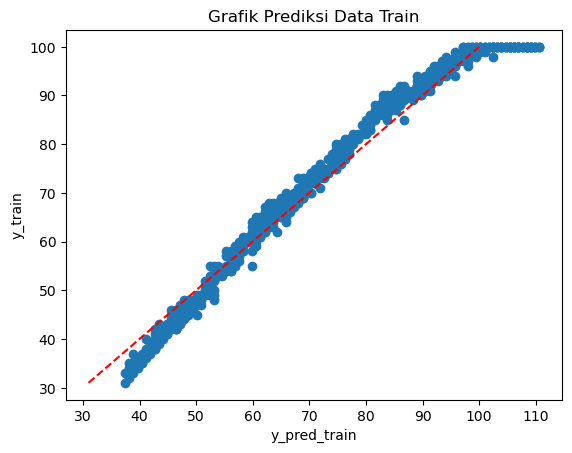

In [27]:
plt.scatter (y_pred_train, y_train)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--r')
plt.title('Grafik Prediksi Data Train')
plt.xlabel('y_pred_train')
plt.ylabel('y_train')
plt.show()

**Modul 6** (GUI)

In [28]:
import tkinter as tk
from tkinter import ttk
from tkinter import messagebox
import pandas as pd

In [29]:
def submit():
    try:
        hours = float(entry_hours.get())
    except ValueError:
        messagebox.showerror("ERROR", 'please inpot by Number')
        return

    x_baru = pd.DataFrame({'study_hours': [hours]})
    x_std = (x_baru - x_train.mean()) / x_train_std
    y_pred_baru = model.predict(x_std).values
    nilai = int(y_pred_baru[0])
    if nilai > 100:
        nilai = 100
    result_label.config(text=f"Nilai {nilai}".replace(",","."))

In [30]:
window = tk.Tk()
window.title("Assignment grade Prediction App")
window.geometry('450x500')
window.configure(bg="#BFBBBB")
window.resizable(False, False)

style = ttk.Style()
style.theme_use('clam')

In [31]:
header_label = tk.Label (
    window,
    text="Assignment Predictor",
    font=('Segoe UI', 20, 'bold'),
    bg='#F0F4F8',
    fg='#1E293B'
)
header_label.pack(pady=(30, 5))

sub_header = tk.Label(
    window,
    text="Prediksi Nilai berdasarkan jam belajar",
    font=('Segoe UI', 10),
    bg='#F0F4F8',
    fg='#64748B'
)
sub_header.pack(pady=(0, 20))

In [32]:
card = tk.Frame(window, bg='#FFFFFF', bd=0, highlightthickness=1, highlightbackground='#E2E8F0')
card.pack(padx=30, pady=10, fill='both', expand=True)

input_label = tk.Label(
    card,
    text="Lama jam belajar (kyk sok iye aja)",
    font=('Segoe UI', 11, 'bold'),
    bg='#FFFFFF',
    fg='#334155'
)
input_label.pack(anchor='w', padx=25, pady=(25, 5))

entry_hours = tk.Entry(
    card,
    font=('Segoe UI', 12),
    bg='#F8FAFC',
    fg='#0F172A',
    bd=1,
    relief='solid',
    justify='center'
)
entry_hours.pack(fill='x', padx=25, ipady=8)

btn_predict = tk.Button(
    card,
    text="Hitungan Prediksi",
    font=('Segoe UI', 11, 'bold'),
    bg='#2563EB',
    fg='white',
    activebackground='#1D4ED8',
    activeforeground='white',
    bd=0,
    cursor='hand2',
    command=submit
)
btn_predict.pack(fill='x', padx=25, pady=20, ipady=8)

In [33]:
result_title = tk.Label(
    card, 
    text="Estimasi Nilai yang akan di dapatkan:",
    font=('Segoe UI', 9),
    bg='#FFFFFF',
    fg='#0F172A'
)
result_title.pack(pady=(0, 25))

result_label = tk.Label(
    card, 
    text="Nilai kosong",
    font=('Segoe UI', 16, 'bold'),
    bg='#FFFFFF',
    fg='#0F172A'
)
result_label.pack(pady=(0, 25))

In [ ]:
window.mainloop()

* Prediksi terkecil yang menyentuh nilai 100 itu 8.5 jam